# Hackaton 2024 - 2025

**Contexte** :

```En 2180, la mégapole qu'est devenue Toulouse est sujette à de
violentes catastrophe naturelles quidétruisent la ville.
Heureusement un groupe de jeunes experts se sont ligués pour
protégé la ville rose des inondations, tremblements de terre,
hackers et autres cataclysmes.
Chaque unité à sa manière a pu mettre en place une solution IT pour
couvrir l'ensemble des menaces possibles.
``` 



## Exploration de donnèes 

In [60]:
import pandas as pd
from pprint import pprint

# Attempt to read the file with a specific encoding
try:
    data = pd.read_csv("catastrophes_naturelles_vf.csv",encoding='latin-1', sep=';')
    pprint("Aperçu des 5 premières lignes du dataset :")
    pprint(data.head())
except UnicodeDecodeError as e:
    pprint(f"UnicodeDecodeError: {e}")
except FileNotFoundError as e:
    pprint(f"FileNotFoundError raised with : {e}")

# Modify data because of misconception 
data['quartier'].replace(
    ["Zone 1", "Zone 2", "Zone 3", "Zone 4", "Zone 5"], ["1", "3", "4", "2", "5"]
)

'Aperçu des 5 premières lignes du dataset\u202f:'
   id  temperature  humidite  force_moyenne_du_vecteur_de_vent  \
0   0          5.7      75.6                               3.8   
1   1          5.7      75.6                               3.8   
2   2          5.7      75.6                               3.8   
3   3          5.7      75.6                               3.8   
4   4          5.7      75.6                               3.8   

   force_du_vecteur_de_vent_max  pluie_intensite_max        date  quartier  \
0                           4.3                  0.0  01/01/2170         1   
1                           4.3                  0.0  01/01/2170         3   
2                           4.3                  0.0  01/01/2170         4   
3                           4.3                  0.0  01/01/2170         2   
4                           4.3                  0.0  01/01/2170         5   

   sismicite  concentration_gaz  pluie_totale  Innondation  seisme  
0       0.62   

0       1
1       3
2       4
3       2
4       5
       ..
3390    1
3391    3
3392    4
3393    2
3394    5
Name: quartier, Length: 3395, dtype: int64

Shape

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

In [61]:

data.shape

(3395, 13)

Features

In [62]:
data.columns

Index(['id', 'temperature', 'humidite', 'force_moyenne_du_vecteur_de_vent',
       'force_du_vecteur_de_vent_max', 'pluie_intensite_max', 'date',
       'quartier', 'sismicite', 'concentration_gaz', 'pluie_totale',
       'Innondation', 'seisme'],
      dtype='object')

Dtypes per features

In [63]:
data.dtypes

id                                    int64
temperature                         float64
humidite                            float64
force_moyenne_du_vecteur_de_vent    float64
force_du_vecteur_de_vent_max        float64
pluie_intensite_max                 float64
date                                 object
quartier                              int64
sismicite                           float64
concentration_gaz                   float64
pluie_totale                        float64
Innondation                           int64
seisme                                int64
dtype: object

Get overview

In [64]:
data.describe()

,id,temperature,humidite,force_moyenne_du_vecteur_de_vent,force_du_vecteur_de_vent_max,pluie_intensite_max,quartier,sismicite,concentration_gaz,pluie_totale,Innondation,seisme
count,3395.000000,3395.000000,3395.000000,3395.000000,3395.000000,3395.000000,3395.000000,3395.000000,3395.000000,3395.000000,3395.000000,3395.000000
mean,1697.000000,23.101178,56.239175,5.796907,11.547275,0.008100,3.000000,0.648162,194.305184,462.217620,0.440353,0.221502
std,980.196409,10.415629,13.473980,3.366256,7.004531,0.031777,1.414422,0.178118,53.029867,271.815926,0.496503,0.415319
min,0.000000,-29.700000,13.400000,1.100000,0.000000,0.000000,1.000000,0.300000,100.080000,0.100000,0.000000,0.000000
25%,848.500000,15.700000,46.700000,3.500000,6.900000,0.000000,2.000000,0.525000,155.320000,229.500000,0.000000,0.000000
50%,1697.000000,21.300000,58.200000,4.700000,10.300000,0.000000,3.000000,0.640000,186.900000,457.730000,0.000000,0.000000
75%,2545.500000,31.300000,66.500000,6.900000,14.600000,0.000000,4.000000,0.790000,236.815000,681.785000,1.000000,0.000000
max,3394.000000,46.300000,84.700000,32.300000,57.600000,0.300000,5.000000,1.000000,299.900000,999.870000,1.000000,1.000000


## Data analysis

We're lucky because we got no features with *string* but date we'll be an issue when drawing the correlation matrix we're going to drop it.

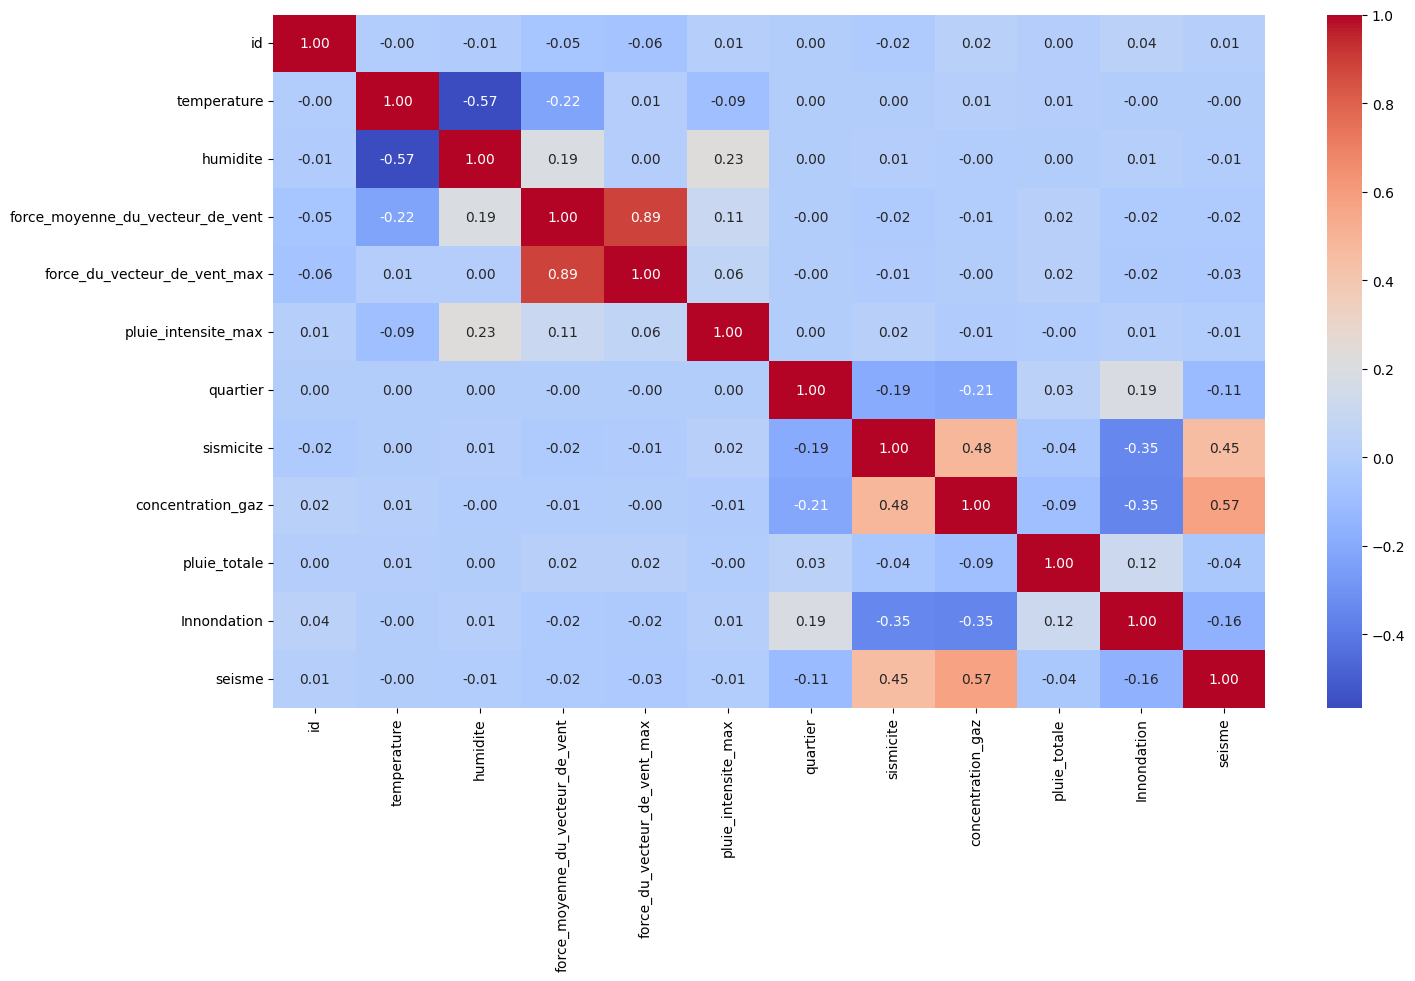

In [65]:
import matplotlib.pyplot as plt
import seaborn as sns

data = data.drop(columns=['date'])

plt.figure(figsize=(16,9))
sns.heatmap(data.corr(), cmap='coolwarm',annot=True, fmt=".2f")
plt.show()


Since we're working with two IOT teams we learned that they can't provide us much information so we are gonna drop (later) some columns which will be not be given by IOT's metrics.

## Models

But before dropping some features we want to try with every data that are available.

In [69]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

In [90]:
# Step 0 : reload the file to go from a fresh start :
train_file_path = 'catastrophes_naturelles_vf.csv'
data = pd.read_csv(train_file_path, delimiter=';')

data['quartier'].replace(
    ["Zone 1", "Zone 2", "Zone 3", "Zone 4", "Zone 5"], ["1", "3", "4", "2", "5"]
)
data.describe()

,id,temperature,humidite,force_moyenne_du_vecteur_de_vent,force_du_vecteur_de_vent_max,pluie_intensite_max,quartier,sismicite,concentration_gaz,pluie_totale,Innondation,seisme
count,3395.000000,3395.000000,3395.000000,3395.000000,3395.000000,3395.000000,3395.000000,3395.000000,3395.000000,3395.000000,3395.000000,3395.000000
mean,1697.000000,23.101178,56.239175,5.796907,11.547275,0.008100,3.000000,0.648162,194.305184,462.217620,0.440353,0.221502
std,980.196409,10.415629,13.473980,3.366256,7.004531,0.031777,1.414422,0.178118,53.029867,271.815926,0.496503,0.415319
min,0.000000,-29.700000,13.400000,1.100000,0.000000,0.000000,1.000000,0.300000,100.080000,0.100000,0.000000,0.000000
25%,848.500000,15.700000,46.700000,3.500000,6.900000,0.000000,2.000000,0.525000,155.320000,229.500000,0.000000,0.000000
50%,1697.000000,21.300000,58.200000,4.700000,10.300000,0.000000,3.000000,0.640000,186.900000,457.730000,0.000000,0.000000
75%,2545.500000,31.300000,66.500000,6.900000,14.600000,0.000000,4.000000,0.790000,236.815000,681.785000,1.000000,0.000000
max,3394.000000,46.300000,84.700000,32.300000,57.600000,0.300000,5.000000,1.000000,299.900000,999.870000,1.000000,1.000000


In [91]:
# Step 1 add column 'Event' which sum 'seisme' and 'innondation'
data['Event'] = 0  # Set column all value to 0 which means 'no events'

data.loc[(data['seisme'] == 1) & (data['Innondation'] == 1),
         'Event'] = 3  # Séisme + Inondation
data.loc[(data['seisme'] == 1) & (
    data['Innondation'] == 0), 'Event'] = 2  # Séisme
data.loc[(data['seisme'] == 0) & (data['Innondation'] == 1),
         'Event'] = 1  # Inondation

# Drop 'date' to get the same data as we had before
# We also drop 'seisme' and 'innondation'
data = data.drop(columns=['date', 'seisme', 'Innondation'])

validation_data = data.sample(n=5,random_state=42)  # Extract validation data
data = data.drop(validation_data.index)  # Drop it from dataset

# Without inplace -> make a new reference to dataframe
X = data.drop(columns=['Event'])
y = data['Event']

# Encode 'quartier
X['quartier'] = LabelEncoder().fit_transform(X['quartier'])

In [92]:
# Step 2 : Split data between train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [93]:
# Step 3 : Grid search to get optimum hyperparameters
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    scoring='accuracy',
    cv=3,
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)

# Best score and parameters associated
best_params = grid_search.best_params_
best_score = grid_search.best_score_
print(
    f"Best hyperparameter and score associated : hyperparameters({best_params}) score({best_score})")

Fitting 3 folds for each of 108 candidates, totalling 324 fits
Best hyperparameter and score associated : hyperparameters({'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 200}) score(0.7474188790560472)


In [94]:
# Step 4 : create model with hyperparameters we got and test it on X_test
RF = RandomForestClassifier(
    n_estimators=300, max_depth=10, min_samples_leaf=1, min_samples_split=10)
# Fit data to the model
RF.fit(X_train, y_train)
# And predict
y_test_pred = RF.predict(X_test)

print("Classification report :")
print(classification_report(y_test, y_test_pred))

print("Confusion matrix :")
print(confusion_matrix(y_test, y_test_pred))



Classification report :
              precision    recall  f1-score   support

           0       0.90      0.54      0.67       257
           1       0.79      0.96      0.86       276
           2       0.73      0.84      0.78       112
           3       0.55      1.00      0.71        33

    accuracy                           0.78       678
   macro avg       0.74      0.83      0.76       678
weighted avg       0.81      0.78      0.77       678

Confusion matrix :
[[138  72  34  13]
 [  5 264   0   7]
 [ 11   0  94   7]
 [  0   0   0  33]]


In [95]:
# # And now let's try on our validation data 
X_val = validation_data.drop(columns=["Event"])
y_val = validation_data['Event']
y_val_pred = RF.predict(X_val)

# # Drumroll
pprint(f"Here's y_val : {y_val.values} and the prediction we made : {y_val_pred}")

"Here's y_val : [0 0 0 2 0] and the prediction we made : [2 1 1 2 1]"


As we can see there's 1 out of 5 value that was correctly predicted. Now let's try with only data that can be provided from IOT.

After discussion from IOT team's we can get : 
